# Duvha Standby Centre - Server Temperature Monitor

**Author:** Erick Chauke

Several servers run day and night at the standby control centre next to the Duvha
power station. Each has a hard drive (HDD, the disk that stores its data) with a
heat sensor, and every half hour the temperature of each server is written to one
logger file. This notebook studies that file to make the room's heat alarm
smarter.

## How the current alarm works

Every so often, Nagios (the monitoring system) runs a short Bash script. It reads
the latest temperature from each server, **drops the single hottest one**, and
averages the rest. The hottest is set aside because one very busy server can run
hot by itself and would unfairly pull the average up. If that average rises
**above 26 degrees**, a warning email goes out to the managers.

Here is that Bash script, the real Nagios code. Only the internal file location
and download address are shown as placeholders; everything else is exactly as it
runs.

```bash
#!/bin/bash

SCC_FILE=/tmp/room_temp.csv
OK_TEMP=26
WARN_TEMP=28
CRITICAL_TEMP=32
OK_CODE=0
WARN_CODE=1
CRIT_CODE=2
UNKN_CODE=3

wget http://<internal-host>/<data-file>.csv -O $SCC_FILE

line=`tail -n 1 $SCC_FILE`
IFS=',' read -ra array <<< "$line"
#Remove the date
unset 'array[0]'

#Sort
new_array=($(echo "${array[@]}" | sed 's/ /\n/g' | sort))
##Remove the highest value
unset 'new_array[3]'
##Array length
len=${#new_array[@]}

sum=0
for (( i=0; i<$len; i++ )); do sum=$sum+${new_array[i]} ; done

DUVHA_TEMP=`echo "scale=1; ($sum)/$len" | bc -l`
DUVHA_TIME=`tail -n 1 $SCC_FILE | awk -v FS=, '{print $1}'`
if (( $(echo "$DUVHA_TEMP <= $OK_TEMP" |bc -l) )); then
    echo "OK - $DUVHA_TIME: Temperature is normal ($DUVHA_TEMP°C)"
    exit $OK_CODE
elif (( $(echo "$DUVHA_TEMP > $OK_TEMP && $DUVHA_TEMP <= $WARN_TEMP" |bc -l) )); then
    echo "WARNING - $DUVHA_TIME: Temperature acceptable ($DUVHA_TEMP°C)"
    exit $WARN_CODE
elif (( $(echo "$DUVHA_TEMP > $WARN_TEMP" |bc -l) )); then
    echo "CRITICAL - $DUVHA_TIME: Temperature too high ($DUVHA_TEMP°C)"
    exit $CRIT_CODE
else
    echo "INFORMATION - $DUVHA_TIME: Connection is not available"
    exit $UNKN_CODE
fi
```

The script reads the way the computer runs it, one line at a time. Each quoted
line below is followed by what it does in plain words.

**Getting the latest reading**

- `SCC_FILE=/tmp/room_temp.csv` - choose a temporary spot to save the downloaded file.
- `OK_TEMP=26`, `WARN_TEMP=28`, `CRITICAL_TEMP=32` - the temperature limits, in degrees.
- `OK_CODE=0` ... `UNKN_CODE=3` - the four status codes Nagios reads (0 is fine, 3 is unknown).
- `wget http://<internal-host>/... -O $SCC_FILE` - download the latest logger file.
- `tail -n 1 $SCC_FILE` - take the last line, the newest reading.
- `IFS=',' read -ra array <<< "$line"` - split that line on its commas into separate values.
- `unset 'array[0]'` - drop the first value, the date and time. What is left is the four temperatures, one per server, all from the same moment.

**Doing the maths and deciding**

- `... | sort` - sort the temperatures from low to high.
- `unset 'new_array[3]'` - remove the single hottest reading. This is the busy-server rule: one hard-working server can run hot on its own, so dropping it stops that single machine from pushing the whole room to a CRITICAL alert.
- `len=${#new_array[@]}` - count how many temperatures are left.
- `for (( ... )); do sum=$sum+...` - add the remaining temperatures together.
- `echo "scale=1; ($sum)/$len" | bc -l` - divide the total by the count for the average, to one decimal place.
- `if ... elif ... else` - compare the average to the limits and print OK, WARNING, CRITICAL, or "connection not available", each with its exit code.

So one run of the script is a single **snapshot**: one combined health reading for
the whole room, taken from the most recent moment.

## The config cell

This is the one place you edit. It says where the data is, how the room
temperature is worked out, and the alarm settings. Run it once before anything else.

In [1]:
# The single control panel. To study a different logger file, drop it into the
# data/ folder and point CSV_PATH at it. Nothing else here normally changes.

import os                        # builds file paths that work on any operating system
import glob                       # finds the data file without naming it
import numpy as np               # fast maths across the columns of readings
import pandas as pd              # reads the CSV into a tidy, spreadsheet-like table
import matplotlib.pyplot as plt  # draws the charts

# --- where things live ------------------------------------------------------
# Resolve the single logger file inside data/ without hard-coding its name.
CSV_PATH = sorted(glob.glob(os.path.join("data", "*.csv")))[0]
OUTPUT_DIR = "output"                         # every chart is saved in this folder
SLUG = "duvha_temp"                           # short prefix put on each chart's file name

# --- how the room temperature is worked out --------------------------------
DROP_HIGHEST = 1   # how many of the hottest servers to set aside before averaging (busy-server rule)

# --- the alarm limits, in degrees Celsius (straight from the Nagios script) -
WARN_SET = 26.0    # the average must go above this to raise a warning
CRIT_SET = 28.0    # above this it is treated as critical

# --- the two calming settings (justified with the data later) --------------
CLEAR_GAP = 1.0    # only sound the all-clear once the average drops this far back below the warning line
PERSIST_N = 2      # how many readings in a row must be over the line before alarming

os.makedirs(OUTPUT_DIR, exist_ok=True)   # create the output folder if it is not there yet

print("Config loaded.")
print(f"  data source  : the logger file in data/")
print(f"  charts saved : {OUTPUT_DIR}/{SLUG}_*.png")
print(f"  warn above {WARN_SET} C, critical above {CRIT_SET} C")
print(f"  all-clear below {WARN_SET - CLEAR_GAP} C, after {PERSIST_N} readings in a row")

Config loaded.
  data source  : the logger file in data/
  charts saved : output/duvha_temp_*.png
  warn above 26.0 C, critical above 28.0 C
  all-clear below 25.0 C, after 2 readings in a row


## Loading the data

The logger file is opened for a first look: how many rows there are, and what the
first few look like.

In [2]:
# Read the CSV into a table and tidy the column names (the header has stray spaces).
raw = pd.read_csv(CSV_PATH)
raw.columns = [name.strip() for name in raw.columns]

# The first column is the timestamp; every column after it is one server. The
# servers are relabelled Server 1, Server 2, ... so no internal hostname appears
# in this notebook; the analysis does not depend on the names.
TIME_COL = raw.columns[0]
original_sensor_cols = [name for name in raw.columns if name != TIME_COL]
SENSOR_COLS = [f"Server {i + 1}" for i in range(len(original_sensor_cols))]
raw = raw.rename(columns=dict(zip(original_sensor_cols, SENSOR_COLS)))

print(f"Rows in the file : {len(raw):,}")
print(f"Servers detected : {len(SENSOR_COLS)}")
for name in SENSOR_COLS:
    print(f"  - {name}")

raw.head()   # show the first five rows as a table for a quick eyeball check

Rows in the file : 55,633
Servers detected : 4
  - Server 1
  - Server 2
  - Server 3
  - Server 4


,Time,Server 1,Server 2,Server 3,Server 4
0,20230101 00:00,28,27.0,26.0,26.0
1,20230101 00:30,28,28.0,26.0,27.0
2,20230101 01:00,28,27.0,25.0,26.0
3,20230101 01:30,28,27.0,25.0,26.0
4,20230101 02:00,28,27.0,25.0,26.0


## Getting the data ready

Real sensor data is never perfect. Before anything is counted, every temperature
is made a proper number and every timestamp a proper date and time. Anything
unreadable is marked as "missing" instead of crashing the notebook.

In [3]:
# A CSV file is read as plain text, but real numbers are needed to do any maths
# on the temperatures. So each server's column is converted, one at a time.
for name in SENSOR_COLS:
    # pd.to_numeric turns text like "28" into the number 28. errors="coerce"
    # means: if a value cannot become a number (a blank or stray text), put NaN
    # ("not a number") there instead of stopping with an error.
    raw[name] = pd.to_numeric(raw[name], errors="coerce")

# The timestamp is also text, like "20230101 00:00". Pandas is told its exact
# shape so it can read it as a real date and time:
#   %Y = 4-digit year, %m = month, %d = day, %H = hour, %M = minute.
# .str.strip() first removes any stray spaces around the text, and errors="coerce"
# again turns anything unreadable into a blank date rather than crashing.
raw["timestamp"] = pd.to_datetime(
    raw[TIME_COL].str.strip(), format="%Y%m%d %H:%M", errors="coerce"
)

print("Readings are now numbers and timestamps are now dates.")
# .min() and .max() find the earliest and latest date, confirming the span.
print(f"Period covered: {raw['timestamp'].min():%Y-%m-%d} to {raw['timestamp'].max():%Y-%m-%d}")

Readings are now numbers and timestamps are now dates.
Period covered: 2023-01-01 to 2026-03-05


## Any problems in the data?

Real logger files pick up small blemishes. Three kinds are tallied here, since the
final script must cope with them:

- **Missing reading** - a blank where a temperature should be, because a sensor
  did not report that half hour. It is marked `NaN` (short for "not a number").
- **Duplicate row** - the exact same line written more than once (same time and
  the same temperatures), usually a logging hiccup that saved the row twice.
- **Off-schedule timestamp** - a reading that did not land on the tidy half-hour
  beat. Readings should arrive at :00 and :30 (for example 14:00, 14:30); a stray
  one like 14:51 is "off schedule".

In [4]:
# Count each kind of imperfection defined just above.

# 1) Missing readings per server. isna() marks every blank as True; adding up the
#    Trues gives the number of blanks in each server's column.
missing_per_sensor = raw[SENSOR_COLS].isna().sum()

# 2) Rows missing at least one reading. any(axis=1) looks along each row and is
#    True if ANY server is blank in that row; summing counts those rows.
rows_any_missing = raw[SENSOR_COLS].isna().any(axis=1).sum()

# 3) Duplicate rows. duplicated() flags a row that is identical to an earlier one
#    (same time and same temperatures); summing counts how many repeats there are.
duplicate_rows = raw.duplicated().sum()

# 4) Off-schedule timestamps. .dt.minute pulls the minutes out of each time. A
#    proper reading sits on :00 or :30, so isin([0, 30]) is True for those. The
#    "~" means "not", so this counts the readings that are NOT on the half-hour.
off_grid = (~raw["timestamp"].dt.minute.isin([0, 30])).sum()

print(f"Rows with a missing reading : {rows_any_missing}")
print(f"Duplicate rows              : {duplicate_rows}")
print(f"Off-schedule timestamps     : {off_grid}")
print("Missing readings per server:")
for name, count in missing_per_sensor.items():
    print(f"  {name}: {count}")

Rows with a missing reading : 47
Duplicate rows              : 3
Off-schedule timestamps     : 4
Missing readings per server:
  Server 1: 0
  Server 2: 6
  Server 3: 45
  Server 4: 5


## A small helper for the charts

Every chart is both saved into the `output/` folder and shown right here in the
notebook. This one small helper does both, so those steps are not repeated for
each chart. Run it once; it prints nothing until a chart uses it.

In [5]:
def save_and_show(figure, name):
    """Save a chart to output/ under the site slug, then display it here."""
    path = os.path.join(OUTPUT_DIR, f"{SLUG}_{name}.png")
    figure.savefig(path, dpi=120, bbox_inches="tight")
    print(f"saved {path}")
    plt.show()

## How complete is the data over time?

A few small gaps were counted earlier. This chart puts them in context: how many
readings actually arrived each month (the bars), against how many would be
expected if none were ever missed (the dashed line).

saved output\duvha_temp_coverage.png


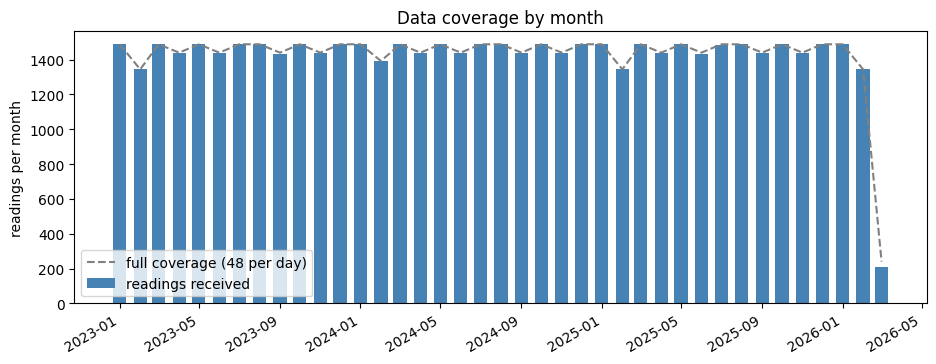

In [6]:
# Count how many readings arrived per day, then roll that up to each month.
readings_per_day = (
    raw.dropna(subset=["timestamp"])   # ignore rows whose time could not be read
       .set_index("timestamp")         # use the time as the row label
       .resample("D").size()           # "D" = per day; size() = how many readings
)
readings_per_month = readings_per_day.resample("MS").sum()   # "MS" = month start
days_in_month = readings_per_day.resample("MS").size()
full_coverage_per_month = days_in_month * 48   # 48 half-hours make a full day

figure, axis = plt.subplots(figsize=(11, 4))
axis.bar(readings_per_month.index, readings_per_month.values,
         width=20, color="steelblue", label="readings received")
axis.plot(full_coverage_per_month.index, full_coverage_per_month.values,
          color="gray", linestyle="--", label="full coverage (48 per day)")
axis.set_title("Data coverage by month")
axis.set_ylabel("readings per month")
axis.legend(loc="lower left")
figure.autofmt_xdate()   # angle the date labels so they do not overlap
save_and_show(figure, "coverage")

**What the chart shows.** The bars (readings actually received) sit right on the
dashed line (full coverage), month after month. So there are no big blackout
periods: the record is essentially complete. The last bar is short only because
March 2026 is a partial month. The tiny gaps counted earlier are far too small to
see here. The takeaway: this data can be trusted, and the real challenge is not
missing readings but how the alarm behaves right at the 26 line.

## Reproducing the alarm's own number

The alarm watches a single number: the average of the servers after the hottest
one is dropped. Here that exact calculation is repeated for every row in the
history, giving one "room number" per half hour. Studying that number over three
years is what reveals the flapping.

In [7]:
temperatures = raw[SENSOR_COLS].values   # the four server readings as a grid of numbers

# For every row: sort the readings low to high, drop the hottest one, and average
# what is left. This is the drop-highest rule from the script, applied to the
# whole history at once. np.sort pushes any blank (NaN) to the end, so a missing
# reading is treated as the "highest" and dropped, which is the sensible choice.
sorted_low_to_high = np.sort(temperatures, axis=1)
kept = sorted_low_to_high[:, :-DROP_HIGHEST]   # every column except the hottest
raw["room_temp"] = np.nanmean(kept, axis=1)    # average of the rest, ignoring blanks

room_temp = raw["room_temp"]
share_over_warn = (room_temp > WARN_SET).mean() * 100

print(f"Lowest room reading  : {room_temp.min():.1f} C")
print(f"Typical (median)     : {room_temp.median():.1f} C")
print(f"Highest room reading : {room_temp.max():.1f} C")
print(f"Share above {WARN_SET:.0f} C     : {share_over_warn:.1f}%")

Lowest room reading  : 21.3 C
Typical (median)     : 24.3 C
Highest room reading : 35.3 C
Share above 26 C     : 6.1%


**What these numbers say.** The typical (median) room number is 24.3 C,
comfortably below the 26 warning line, so most of the time the room is fine. Yet
the highest it reached was 35.3 C, and for 6.1% of all readings it sits above 26.
That 6.1% is the important part: it is not one long hot spell but many brief
crossings clustered right at the line. Those repeated crossings are what generate
the stream of emails. The next section pins down exactly where the number sits
relative to the limits.

## Confirming the limits

Two things to check against the data: does the warning really fire above 26 (as
the boss described), and how often does the room number reach each limit in the
script?

In [8]:
# Count how often the room number climbs above each limit. The three limits are
# the warning line (26), the critical limit the script actually uses (28), and the
# value 32 that the script sets but never checks (explained just below).
for limit, label in [(WARN_SET, "warning, above 26"),
                     (CRIT_SET, "critical actually used, above 28"),
                     (32.0, "the unused 32 setting")]:
    above = room_temp > limit
    print(f"{label:<34}: {above.sum():>6,} readings  ({above.mean() * 100:.2f}%)")

warning, above 26                 :  3,368 readings  (6.05%)
critical actually used, above 28  :     36 readings  (0.06%)
the unused 32 setting             :      9 readings  (0.02%)


**Confirmed, with one quirk.** The warning does fire above 26, exactly as
described. But the script hides a small bug: it sets `CRITICAL_TEMP=32` and then
never uses it. The critical test actually compares against `WARN_TEMP` (28), so in
practice the room is called CRITICAL above **28**, and the 32 setting does nothing
at all. The counts above show the real effect: the number passes 28 only rarely
and reaches 32 almost never. The improved script removes this trap by making every
limit an explicit, live setting, so a value can never be set and then silently
ignored again.

## Where does the room number spend its time?

This chart counts how often the room number lands in each half-degree band, with
the warning line (26) and the critical line (28) drawn on top. The shape shows why
the flapping happens.

saved output\duvha_temp_distribution.png


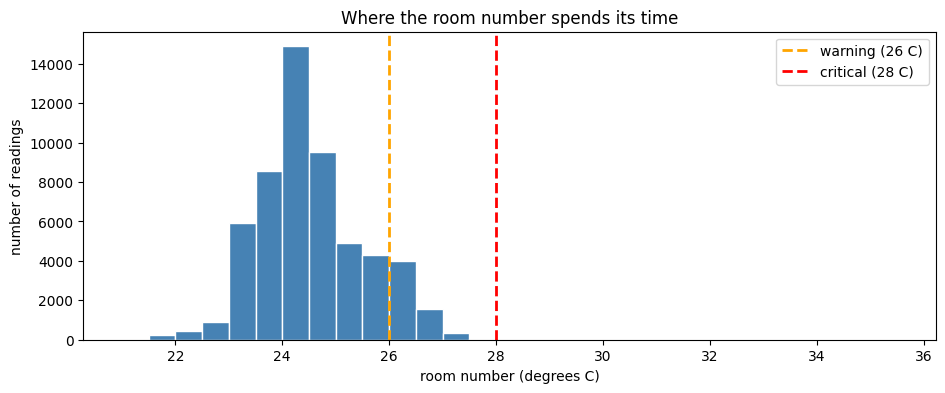

In [9]:
figure, axis = plt.subplots(figsize=(11, 4))

# One bar per half-degree band, so the shape of the distribution is easy to read.
bands = np.arange(21, 36, 0.5)
axis.hist(room_temp.dropna(), bins=bands, color="steelblue", edgecolor="white")

# Mark the two limits that matter.
axis.axvline(WARN_SET, color="orange", linestyle="--", linewidth=2, label=f"warning ({WARN_SET:.0f} C)")
axis.axvline(CRIT_SET, color="red", linestyle="--", linewidth=2, label=f"critical ({CRIT_SET:.0f} C)")

axis.set_title("Where the room number spends its time")
axis.set_xlabel("room number (degrees C)")
axis.set_ylabel("number of readings")
axis.legend()
save_and_show(figure, "distribution")

**What the shape shows.** The room number piles up between about 23 and 26, with
its peak near 24. The warning line at 26 sits right on the upper shoulder of that
pile, not out in an empty tail. That is the whole problem in one picture: because
so many normal readings already sit at 25 to 26, the smallest upward wiggle tips
the number over 26 and straight back, again and again. The critical line at 28
sits far out in the thin tail, which is why genuine critical heat is rare. A good
fix must calm the crossings at 26 without ignoring a real climb into that tail.

## The flapping, made visible

The charts so far show the problem from a distance. Here the notebook finds the
single worst week (the one with the most crossings of the 26 line) and zooms right
in, so each individual crossing can be seen.

Flappiest week ends 2023-01-08, with 48 crossings


saved output\duvha_temp_flapping_week.png


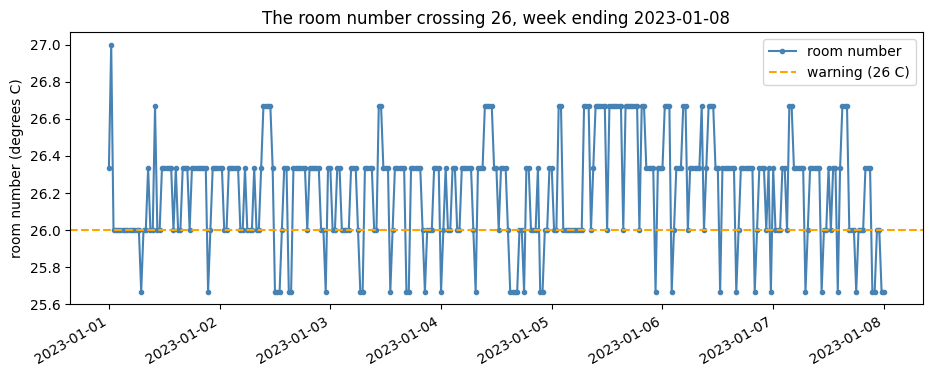

In [10]:
# Put the room number on a time axis so a window of dates can be sliced out.
room_over_time = pd.Series(room_temp.values, index=raw["timestamp"]).sort_index()

# A "crossing" is the number going from at-or-below 26 up to above 26.
above_line = room_over_time > WARN_SET
crossings = above_line & ~above_line.shift(1, fill_value=False)

# Find the calendar week with the most crossings, then take that seven-day window.
crossings_per_week = crossings.resample("W").sum()
busiest_week_end = crossings_per_week.idxmax()
window = room_over_time.loc[busiest_week_end - pd.Timedelta(days=7):busiest_week_end]
print(f"Flappiest week ends {busiest_week_end:%Y-%m-%d}, with {int(crossings_per_week.max())} crossings")

figure, axis = plt.subplots(figsize=(11, 4))
axis.plot(window.index, window.values, color="steelblue", marker=".", label="room number")
axis.axhline(WARN_SET, color="orange", linestyle="--", label="warning (26 C)")
axis.set_title(f"The room number crossing 26, week ending {busiest_week_end:%Y-%m-%d}")
axis.set_ylabel("room number (degrees C)")
axis.legend()
figure.autofmt_xdate()
save_and_show(figure, "flapping_week")

**What the zoom shows.** The line pokes above the orange 26 line and drops back
under it over and over within the same few days. Every single one of those upward
pokes is a fresh alarm email under the current script, even though the room is
merely wobbling around the same level. This is the nuisance-alarm problem in its
rawest form, and it is exactly what hysteresis and persistence are built to calm.

## How long does each breach last?

One crossing is not the whole story: what matters is how long the room stays over
the line each time. A "breach episode" is one unbroken run of readings above 26.
Counting how long these last shows how many are just brief blips.

Breach episodes (times the room went over 26): 770
  just one reading (<= 30 min)   : 169 (22%)
  an hour or less  (<= 2 readings): 314 (41%)
  median length: 3 readings (1.5 hours)


saved output\duvha_temp_breach_lengths.png


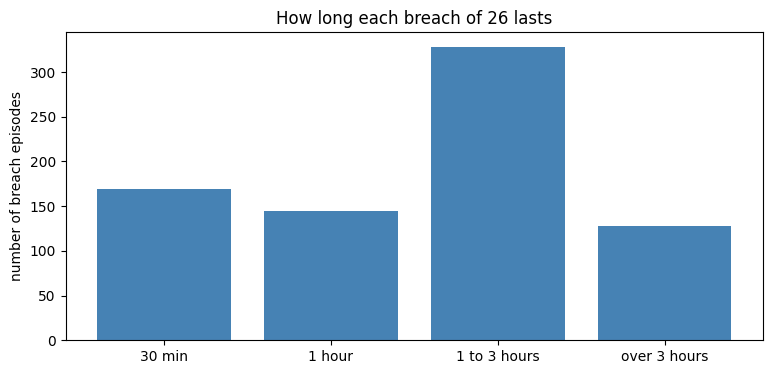

In [11]:
# Group readings into episodes: unbroken runs of being above the 26 line.
above = room_over_time > WARN_SET
run_id = (above != above.shift()).cumsum()          # a new id each time it flips
runs = above.groupby(run_id).agg(state="first", length="size")
breach_lengths = runs.loc[runs["state"], "length"]  # keep only the above-the-line runs

total = len(breach_lengths)
single = (breach_lengths <= 1).sum()
under_hour = (breach_lengths <= 2).sum()
print(f"Breach episodes (times the room went over 26): {total}")
print(f"  just one reading (<= 30 min)   : {single} ({single / total * 100:.0f}%)")
print(f"  an hour or less  (<= 2 readings): {under_hour} ({under_hour / total * 100:.0f}%)")
print(f"  median length: {breach_lengths.median():.0f} readings ({breach_lengths.median() * 0.5:.1f} hours)")

# Sort the episode lengths into easy-to-read time buckets and chart them.
hours = breach_lengths * 0.5   # each reading is half an hour
buckets = pd.cut(hours, bins=[0, 0.5, 1, 3, 1000],
                 labels=["30 min", "1 hour", "1 to 3 hours", "over 3 hours"])
counts = buckets.value_counts().reindex(["30 min", "1 hour", "1 to 3 hours", "over 3 hours"])

figure, axis = plt.subplots(figsize=(9, 4))
axis.bar(counts.index, counts.values, color="steelblue")
axis.set_title("How long each breach of 26 lasts")
axis.set_ylabel("number of breach episodes")
save_and_show(figure, "breach_lengths")

**A large share of breaches are just blips.** Across the three years the room
number went over 26 about 770 separate times. Nearly a quarter of those lasted a
single reading: the number popped over 26 for one half hour and was straight back.
Around four in ten were gone within an hour, and only about one in six ran longer
than three hours. So some breaches are genuinely long, but a big fraction are
short boundary blips that carry no new information: the room is not heating up, it
is nudging the line. The fix should silence the short blips while leaving the
genuinely long, hot episodes to alarm as before.

## Testing the fixes on the real history

The two calming ideas can now be judged on evidence. Each rule is replayed across
the full three years, counting how many alarm emails it would have sent. Fewer
emails is better, but only if genuine heat still gets through.

In [12]:
# Each helper replays the history and counts alarm emails. An "alarm" is one
# switch from calm to alarming; staying alarmed does not count again.

def count_hysteresis(values, warn, clear):
    """Alarm turns on above `warn`, and only off once it drops below `clear`."""
    alarms, alarmed = 0, False
    for value in values:
        if not alarmed and value > warn:
            alarmed, alarms = True, alarms + 1
        elif alarmed and value < clear:
            alarmed = False
    return alarms

def count_persistence(values, warn, n):
    """Alarm needs `n` readings in a row above `warn` before it fires."""
    alarms, run, armed = 0, 0, True
    for value in values:
        if value > warn:
            run += 1
            if run >= n and armed:
                alarms, armed = alarms + 1, False
        else:
            run, armed = 0, True
    return alarms

def count_combined(values, warn, clear, n):
    """Both rules together: needs `n` in a row to fire, clears below `clear`."""
    alarms, alarmed, run = 0, False, 0
    for value in values:
        run = run + 1 if value > warn else 0
        if not alarmed and run >= n:
            alarmed, alarms = True, alarms + 1
        elif alarmed and value < clear:
            alarmed = False
    return alarms

print("Three alarm-counting rules defined.")

Three alarm-counting rules defined.


### How many emails does each rule send?

The current script alarms on every crossing above 26. The chart compares that
against hysteresis alone, persistence alone, and the two combined.

current     : 770 alarm emails
hysteresis  : 146 alarm emails
persistence : 601 alarm emails
combined    : 108 alarm emails


saved output\duvha_temp_fix_comparison.png


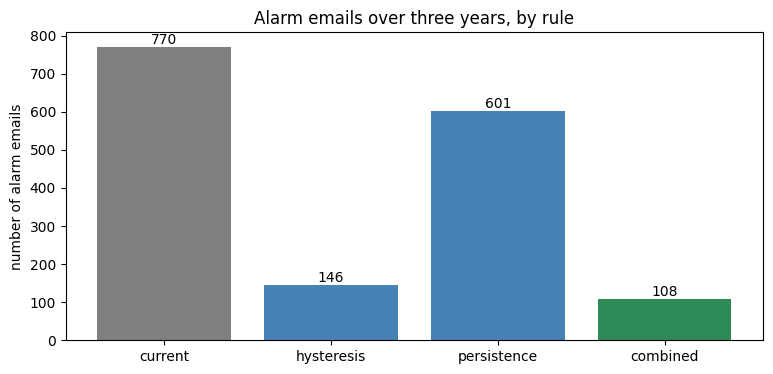

In [13]:
values = room_over_time.values
clear_line = WARN_SET - CLEAR_GAP   # 26 - 1 = 25

# The current script fires on every crossing above 26 (the baseline to beat).
baseline = int((above_line & ~above_line.shift(1, fill_value=False)).sum())

labels = ["current", "hysteresis", "persistence", "combined"]
counts = [
    baseline,
    count_hysteresis(values, WARN_SET, clear_line),
    count_persistence(values, WARN_SET, PERSIST_N),
    count_combined(values, WARN_SET, clear_line, PERSIST_N),
]
for label, count in zip(labels, counts):
    print(f"{label:<12}: {count} alarm emails")

figure, axis = plt.subplots(figsize=(9, 4))
axis.bar(labels, counts, color=["gray", "steelblue", "steelblue", "seagreen"])
axis.set_title("Alarm emails over three years, by rule")
axis.set_ylabel("number of alarm emails")
for x, count in enumerate(counts):
    axis.text(x, count, str(count), ha="center", va="bottom")
save_and_show(figure, "fix_comparison")

**The two together win.** Persistence alone barely helps: most flapping breaches
last more than one reading, so a two-in-a-row test still lets them through.
Hysteresis alone is far stronger, because the wide gap down to 25 stops the
on-off chatter. Combining them is best of all, cutting the three-year total from
770 emails to about 108, a drop of roughly 86 percent. This is not achieved by
ignoring heat: every genuinely long, hot spell still raises its alarm. Only the
short boundary blips are removed.

### Fine-tuning: why a gap of 1 and a streak of 2

Bigger settings send fewer emails, but at a cost: a wider gap makes the alarm
slower to clear, and a longer streak makes it slower to fire. The table below
shows the combined-rule email count across a range of both, so a sensible balance
can be chosen rather than simply the most aggressive setting.

In [14]:
print(f"{'clear below':>12} | {'N=2':>5} {'N=3':>5} {'N=4':>5}")
print("-" * 34)
for gap in [0.5, 1.0, 1.5, 2.0]:
    row = [count_combined(values, WARN_SET, WARN_SET - gap, n) for n in (2, 3, 4)]
    print(f"{WARN_SET - gap:>12} | {row[0]:>5} {row[1]:>5} {row[2]:>5}")

 clear below |   N=2   N=3   N=4
----------------------------------
        25.5 |   159   123   104
        25.0 |   108    82    65
        24.5 |    86    61    48
        24.0 |    67    50    39


**The chosen balance.** Most of the improvement comes from opening the gap to 25
with a two-in-a-row streak: 108 emails. Going further keeps shaving the count, but
each extra step buys little while making the alarm stickier and slower to react. A
clear line at 25 and a streak of 2 keeps the alarm responsive (it still fires
within an hour of a real rise) while removing about 86 percent of the noise. Those
are the values carried into the config: `CLEAR_GAP = 1.0` and `PERSIST_N = 2`.

## Recommendation

The evidence supports one clear change to the alarm rule, using the settings just
chosen:

- **Warn above 26** - unchanged, and confirmed against both the code and the brief.
- **Only clear below 25** (hysteresis, `CLEAR_GAP = 1.0`) - stops the on-off chatter.
- **Require two readings in a row** (persistence, `PERSIST_N = 2`) - ignores single blips.
- **Critical above 28**, now an explicit setting (fixing the unused `CRITICAL_TEMP = 32`).

Over the three-year record this cuts alarm emails from about 770 to 108, a drop of
roughly 86 percent, while still raising every genuinely long, hot spell. These
exact values are copied into the improved `check_temp.sh`.

For a team that prefers to change nothing in the script, Nagios has a built-in
version of the persistence idea: its soft and hard states, set by
`max_check_attempts`, can require several failed checks before emailing. That is a
reasonable partial fix on its own, but it does not add the hysteresis gap that does
most of the work here.

## The improved check, and what to expect from it

The chosen rule is built into a rewritten `check_temp.sh`. A single block at the
top of the script carries the settings proven above: warn above 26, clear below
25, two readings in a row, critical above 28. On each run it replays the last day
of readings rather than judging one instant, so the calming rules can take effect.

Expected behaviour, confirmed by testing the script against crafted inputs:

- A calm room reads OK.
- A single reading that pokes over 26 and drops straight back is ignored and stays
  OK: the two-in-a-row rule filters it out.
- A sustained rise reports WARNING, and a sustained climb past 28 reports CRITICAL.
- One busy server running hot on its own does not raise an alarm, because its
  reading is the single value dropped before averaging.
- Once a warning is on, it holds until the number falls below 25, so a wobble
  between 25 and 26 no longer switches it on and off.
- A missing or unreadable latest reading reports UNKNOWN, never a false OK.

The result uses the standard Nagios exit codes: 0 for OK, 1 for WARNING, 2 for
CRITICAL, 3 for UNKNOWN. Across the three-year record this turns roughly 770 alarm
emails into about 108, while still raising every genuinely long, hot spell.

## Conclusion

The brief asked for three things: confirm the alarm's limits from the code,
measure the nuisance-alarm problem, and propose a sound response.

- **Limits confirmed.** The alarm warns above 26. The code also carries a dead
  setting, `CRITICAL_TEMP = 32`, that never takes effect, so critical in practice
  fires above 28.
- **Flapping measured.** The room number sits right on the 26 line, crossing it
  about 770 times in three years, and a large share of those breaches last under
  an hour.
- **Response justified by data.** Adding hysteresis (clear below 25) and
  persistence (two readings in a row) removes about 86 percent of the alarm emails
  while still catching every long, genuine hot spell. These settings are built
  into the improved `check_temp.sh`.

The alarms were never false, so nothing here hides real heat: it simply stops the
same mild warmth from being reported over and over. Changing nothing remains a
defensible choice, but the small, well-understood change proposed here removes the
noise at no cost to safety.